# SARIMAX: Baseline vs 3-Month Lag Comparison with Backtesting

**Objective**: Compare two models to see if 3-month lagged exog variables improve CPI forecasting

**Models**:
1. **Baseline**: Current exog values only (importprice, total_empties, total_loaded_outbound, total_teus)
2. **Lag-3**: Only 3-month lagged versions of the same variables

**Validation**: 5-fold rolling window backtesting

**Metrics**: MAPE (%) and RMSE (CPI index points)

In [1]:
# Imports
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

print('✓ Libraries loaded')

✓ Libraries loaded


In [2]:
# Load data
df = pd.read_csv('inflationship_output/ports_with_cpi_full_totals.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').set_index('date')
df.index = pd.DatetimeIndex(df.index).to_period('M').to_timestamp('M')  # Ensure month start

print(f'Data: {len(df)} rows from {df.index.min().date()} to {df.index.max().date()}')
print(f'Columns: {list(df.columns)[:10]}...')  # Show first 10 columns

Data: 129 rows from 2015-01-31 to 2025-09-30
Columns: ['total_loaded_lb_x', 'total_empties_la_x', 'cpi_all', 'cpi_food', 'cpi_apparel', 'cpi_vehicles', 'cpi_pharma', 'cpi_household', 'importprice', 'gscpi']...


In [3]:
# Define CPI series and exog variables
CPI_COLS = ['cpi_all', 'cpi_food', 'cpi_apparel', 'cpi_vehicles', 'cpi_pharma', 'cpi_household']
CPI_COLS = [c for c in CPI_COLS if c in df.columns]

EXOG_VARS = ['importprice', 'total_empties', 'total_loaded_outbound', 'total_teus']
EXOG_VARS = [v for v in EXOG_VARS if v in df.columns]

print(f'CPI series to model ({len(CPI_COLS)}): {CPI_COLS}')
print(f'Exog variables ({len(EXOG_VARS)}): {EXOG_VARS}')

CPI series to model (6): ['cpi_all', 'cpi_food', 'cpi_apparel', 'cpi_vehicles', 'cpi_pharma', 'cpi_household']
Exog variables (4): ['importprice', 'total_empties', 'total_loaded_outbound', 'total_teus']


In [4]:
# Create 3-month lagged features
print('Creating 3-month lagged exog features...')

for var in EXOG_VARS:
    df[f'{var}_lag3'] = df[var].shift(3)

LAG3_VARS = [f'{var}_lag3' for var in EXOG_VARS]

print(f'✓ Created {len(LAG3_VARS)} lagged features: {LAG3_VARS}')
print(f'  Note: First 3 rows will have NaN for lag3 features')

Creating 3-month lagged exog features...
✓ Created 4 lagged features: ['importprice_lag3', 'total_empties_lag3', 'total_loaded_outbound_lag3', 'total_teus_lag3']
  Note: First 3 rows will have NaN for lag3 features


## Helper Functions

In [5]:
def calculate_metrics(actual, predicted):
    """
    Calculate MAPE (%) and RMSE
    """
    # Align indices
    common_idx = actual.index.intersection(predicted.index)
    if len(common_idx) == 0:
        return np.nan, np.nan
    
    actual = actual.loc[common_idx]
    predicted = predicted.loc[common_idx]
    
    # Remove any NaN
    mask = ~(actual.isna() | predicted.isna())
    actual = actual[mask]
    predicted = predicted[mask]
    
    if len(actual) == 0:
        return np.nan, np.nan
    
    mape = mean_absolute_percentage_error(actual, predicted) * 100
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    
    return mape, rmse


def fit_sarimax_safe(train_series, exog_train, order=(1,1,1), seasonal_order=(1,1,1,12)):
    """
    Fit SARIMAX with error handling and convergence checks
    """
    try:
        model = SARIMAX(
            train_series, 
            exog=exog_train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
            trend='c'
        )
        
        result = model.fit(disp=False, maxiter=1000, method='lbfgs')
        converged = result.mle_retvals.get('converged', False)
        
        return result, converged, None
        
    except Exception as e:
        return None, False, str(e)


def rolling_backtest(series, exog, order, seasonal_order, n_folds=5, horizon=12):
    """
    Perform rolling window backtesting
    
    Returns list of dicts with metrics for each fold
    """
    results = []
    min_train_size = 36  # Minimum 3 years
    
    # Calculate fold origins
    max_origin = len(series) - horizon
    if max_origin <= min_train_size:
        print(f'    ⚠️  Not enough data: need {min_train_size + horizon}, have {len(series)}')
        return []
    
    origins = np.linspace(min_train_size, max_origin, n_folds, dtype=int)
    
    for fold_num, origin in enumerate(origins, 1):
        try:
            # Split
            train_y = series.iloc[:origin]
            test_y = series.iloc[origin:origin+horizon]
            
            if len(test_y) < horizon:
                continue
            
            # Prepare exog
            if exog is not None and len(exog) > 0:
                train_x = exog.loc[train_y.index]
                test_x = exog.loc[test_y.index]
            else:
                train_x = None
                test_x = None
            
            # Fit
            result, converged, error = fit_sarimax_safe(train_y, train_x, order, seasonal_order)
            
            if result is None:
                print(f'    Fold {fold_num}/{n_folds}: Fit failed - {error}')
                continue
            
            # Forecast
            forecast = result.get_forecast(steps=horizon, exog=test_x)
            pred = forecast.predicted_mean
            
            # Metrics
            mape, rmse = calculate_metrics(test_y, pred)
            
            results.append({
                'fold': fold_num,
                'train_size': len(train_y),
                'test_start': test_y.index[0],
                'test_end': test_y.index[-1],
                'mape': mape,
                'rmse': rmse,
                'aic': result.aic,
                'converged': converged
            })
            
        except Exception as e:
            print(f'    Fold {fold_num}/{n_folds}: Failed - {e}')
            continue
    
    return results

print('✓ Helper functions defined')

✓ Helper functions defined


## Configuration

In [6]:
# Backtesting configuration
N_FOLDS = 5
HORIZON = 12  # months

# Use simple ARIMA orders for better convergence
# These were selected based on typical CPI patterns
ORDERS = {
    'cpi_all': ((1,1,1), (1,1,1,12)),
    'cpi_food': ((1,1,1), (1,1,1,12)),
    'cpi_apparel': ((1,1,1), (0,1,1,12)),
    'cpi_vehicles': ((1,1,1), (1,1,1,12)),
    'cpi_pharma': ((1,1,1), (0,1,1,12)),
    'cpi_household': ((1,1,1), (1,1,1,12))
}

# Default if not specified
DEFAULT_ORDER = (1, 1, 1)
DEFAULT_SEASONAL = (1, 1, 1, 12)

print(f'Configuration:')
print(f'  Folds: {N_FOLDS}')
print(f'  Forecast horizon: {HORIZON} months')
print(f'  ARIMA orders: Simplified for convergence')

Configuration:
  Folds: 5
  Forecast horizon: 12 months
  ARIMA orders: Simplified for convergence


## Run Backtesting: Baseline vs Lag-3 Models

In [7]:
# Storage
all_results = []

print('='*80)
print('BACKTESTING: BASELINE vs LAG-3 MODELS')
print('='*80)
print(f'{N_FOLDS}-fold rolling window, {HORIZON}-month horizon\n')

for cpi_name in CPI_COLS:
    print(f'\n{"="*80}')
    print(f'CPI Series: {cpi_name.upper()}')
    print(f'{"="*80}')
    
    # Get series
    y = df[cpi_name].dropna()
    
    if len(y) < 48:
        print(f'  ⚠️  Skipping: only {len(y)} observations (need ≥48)')
        continue
    
    # Get ARIMA order
    if cpi_name in ORDERS:
        order, seasonal = ORDERS[cpi_name]
    else:
        order, seasonal = DEFAULT_ORDER, DEFAULT_SEASONAL
    
    print(f'  ARIMA order: {order}x{seasonal}')
    print(f'  Data: {len(y)} observations ({y.index.min().date()} to {y.index.max().date()})')
    
    # === MODEL 1: BASELINE (current exog) ===
    print(f'\n  [1/2] BASELINE MODEL (current exog values)...')
    
    exog_baseline = df[EXOG_VARS].reindex(y.index)
    exog_baseline = exog_baseline.fillna(method='ffill').fillna(method='bfill')
    
    baseline_results = rolling_backtest(y, exog_baseline, order, seasonal, N_FOLDS, HORIZON)
    
    if baseline_results:
        df_base = pd.DataFrame(baseline_results)
        mape_mean = df_base['mape'].mean()
        mape_std = df_base['mape'].std()
        rmse_mean = df_base['rmse'].mean()
        rmse_std = df_base['rmse'].std()
        n_conv = df_base['converged'].sum()
        
        print(f'    MAPE: {mape_mean:.2f}% ± {mape_std:.2f}%')
        print(f'    RMSE: {rmse_mean:.3f} ± {rmse_std:.3f}')
        print(f'    Converged: {n_conv}/{len(baseline_results)} folds {"✓" if n_conv >= 4 else "⚠️"}')
    else:
        print(f'    ❌ Failed')
        mape_mean = mape_std = rmse_mean = rmse_std = np.nan
        n_conv = 0
    
    # === MODEL 2: LAG-3 (3-month lagged exog) ===
    print(f'\n  [2/2] LAG-3 MODEL (3-month lagged exog)...')
    
    exog_lag3 = df[LAG3_VARS].reindex(y.index)
    # Drop rows with NaN from lag3 (first 3 rows)
    valid_idx = exog_lag3.dropna().index
    y_lag3 = y.loc[valid_idx]
    exog_lag3 = exog_lag3.loc[valid_idx]
    
    print(f'    Using {len(y_lag3)} observations (dropped {len(y) - len(y_lag3)} due to lag)')
    
    lag3_results = rolling_backtest(y_lag3, exog_lag3, order, seasonal, N_FOLDS, HORIZON)
    
    if lag3_results:
        df_lag3 = pd.DataFrame(lag3_results)
        mape_lag_mean = df_lag3['mape'].mean()
        mape_lag_std = df_lag3['mape'].std()
        rmse_lag_mean = df_lag3['rmse'].mean()
        rmse_lag_std = df_lag3['rmse'].std()
        n_conv_lag = df_lag3['converged'].sum()
        
        print(f'    MAPE: {mape_lag_mean:.2f}% ± {mape_lag_std:.2f}%')
        print(f'    RMSE: {rmse_lag_mean:.3f} ± {rmse_lag_std:.3f}')
        print(f'    Converged: {n_conv_lag}/{len(lag3_results)} folds {"✓" if n_conv_lag >= 4 else "⚠️"}')
    else:
        print(f'    ❌ Failed')
        mape_lag_mean = mape_lag_std = rmse_lag_mean = rmse_lag_std = np.nan
        n_conv_lag = 0
    
    # === COMPARISON ===
    mape_diff = mape_mean - mape_lag_mean
    rmse_diff = rmse_mean - rmse_lag_mean
    
    print(f'\n  {"-"*60}')
    print(f'  COMPARISON')
    print(f'  {"-"*60}')
    print(f'  MAPE: Baseline {mape_mean:.2f}% vs Lag-3 {mape_lag_mean:.2f}%')
    print(f'        Difference: {mape_diff:+.2f}% (positive = Lag-3 better)')
    print(f'  RMSE: Baseline {rmse_mean:.3f} vs Lag-3 {rmse_lag_mean:.3f}')
    print(f'        Difference: {rmse_diff:+.3f} (positive = Lag-3 better)')
    
    if mape_diff > 0 and rmse_diff > 0:
        winner = '🏆 Lag-3 model is better!'
    elif mape_diff < 0 and rmse_diff < 0:
        winner = '🏆 Baseline model is better!'
    else:
        winner = '⚖️  Mixed results'
    
    print(f'  {winner}')
    
    # Store
    all_results.append({
        'cpi_series': cpi_name,
        'order': f'{order}x{seasonal}',
        'n_obs': len(y),
        # Baseline
        'baseline_mape': mape_mean,
        'baseline_mape_std': mape_std,
        'baseline_rmse': rmse_mean,
        'baseline_rmse_std': rmse_std,
        'baseline_converged': n_conv,
        # Lag-3
        'lag3_mape': mape_lag_mean,
        'lag3_mape_std': mape_lag_std,
        'lag3_rmse': rmse_lag_mean,
        'lag3_rmse_std': rmse_lag_std,
        'lag3_converged': n_conv_lag,
        # Differences
        'mape_improvement': mape_diff,
        'rmse_improvement': rmse_diff
    })

print(f'\n{"="*80}')
print('ALL MODELS COMPLETED')
print(f'{"="*80}')

BACKTESTING: BASELINE vs LAG-3 MODELS
5-fold rolling window, 12-month horizon


CPI Series: CPI_ALL
  ARIMA order: (1, 1, 1)x(1, 1, 1, 12)
  Data: 128 observations (2015-01-31 to 2025-08-31)

  [1/2] BASELINE MODEL (current exog values)...


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.wa

    MAPE: 0.77% ± 0.62%
    RMSE: 2.432 ± 1.953
    Converged: 0/5 folds ⚠️

  [2/2] LAG-3 MODEL (3-month lagged exog)...
    Using 125 observations (dropped 3 due to lag)


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.wa

    MAPE: 1.05% ± 0.66%
    RMSE: 3.689 ± 2.568
    Converged: 1/5 folds ⚠️

  ------------------------------------------------------------
  COMPARISON
  ------------------------------------------------------------
  MAPE: Baseline 0.77% vs Lag-3 1.05%
        Difference: -0.28% (positive = Lag-3 better)
  RMSE: Baseline 2.432 vs Lag-3 3.689
        Difference: -1.256 (positive = Lag-3 better)
  🏆 Baseline model is better!

CPI Series: CPI_FOOD
  ARIMA order: (1, 1, 1)x(1, 1, 1, 12)
  Data: 128 observations (2015-01-31 to 2025-08-31)

  [1/2] BASELINE MODEL (current exog values)...


...

    MAPE: 1.09% ± 0.75%
    RMSE: 7.048 ± 4.341
    Converged: 0/5 folds ⚠️

  ------------------------------------------------------------
  COMPARISON
  ------------------------------------------------------------
  MAPE: Baseline 1.11% vs Lag-3 1.09%
        Difference: +0.02% (positive = Lag-3 better)
  RMSE: Baseline 6.618 vs Lag-3 7.048
        Difference: -0.430 (positive = Lag-3 better)
  ⚖️  Mixed results

CPI Series: CPI_HOUSEHOLD
  ARIMA order: (1, 1, 1)x(1, 1, 1, 12)
  Data: 128 observations (2015-01-31 to 2025-08-31)

  [1/2] BASELINE MODEL (current exog values)...


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.wa

    MAPE: 1.07% ± 1.01%
    RMSE: 4.009 ± 3.912
    Converged: 0/5 folds ⚠️

  [2/2] LAG-3 MODEL (3-month lagged exog)...
    Using 125 observations (dropped 3 due to lag)


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.wa

    MAPE: 0.96% ± 0.90%
    RMSE: 3.528 ± 3.468
    Converged: 0/5 folds ⚠️

  ------------------------------------------------------------
  COMPARISON
  ------------------------------------------------------------
  MAPE: Baseline 1.07% vs Lag-3 0.96%
        Difference: +0.11% (positive = Lag-3 better)
  RMSE: Baseline 4.009 vs Lag-3 3.528
        Difference: +0.482 (positive = Lag-3 better)
  🏆 Lag-3 model is better!

ALL MODELS COMPLETED


## Summary Results

In [8]:
# Create summary DataFrame
results_df = pd.DataFrame(all_results)

if len(results_df) > 0:
    # Display table
    display_cols = [
        'cpi_series', 'order', 'n_obs',
        'baseline_mape', 'baseline_converged',
        'lag3_mape', 'lag3_converged',
        'mape_improvement', 'rmse_improvement'
    ]
    
    display_df = results_df[display_cols].copy()
    display_df.columns = [
        'CPI Series', 'Order', 'N',
        'Base MAPE (%)', 'Base Conv',
        'Lag3 MAPE (%)', 'Lag3 Conv',
        'MAPE Δ', 'RMSE Δ'
    ]
    
    # Round
    for col in ['Base MAPE (%)', 'Lag3 MAPE (%)', 'MAPE Δ', 'RMSE Δ']:
        display_df[col] = display_df[col].round(2)
    
    print('\n' + '='*100)
    print('SUMMARY: BASELINE vs LAG-3 COMPARISON')
    print('='*100)
    print(f'{N_FOLDS}-fold rolling window backtesting, {HORIZON}-month horizon')
    print('Positive Δ = Lag-3 model performed better\n')
    
    display(display_df)
    
    # Overall statistics
    print('\n' + '='*100)
    print('OVERALL STATISTICS')
    print('='*100)
    
    # Filter to well-converged models
    well_converged = (results_df['baseline_converged'] >= 4) & (results_df['lag3_converged'] >= 4)
    n_well = well_converged.sum()
    
    print(f'Models with good convergence (≥4/{N_FOLDS} folds): {n_well}/{len(results_df)}')
    
    if n_well > 0:
        df_good = results_df[well_converged]
        
        print(f'\nFor well-converged models:')
        print(f'  Average MAPE improvement: {df_good["mape_improvement"].mean():.2f}%')
        print(f'  Average RMSE improvement: {df_good["rmse_improvement"].mean():.3f}')
        print(f'  Lag-3 better (MAPE): {(df_good["mape_improvement"] > 0).sum()}/{n_well}')
        print(f'  Lag-3 better (RMSE): {(df_good["rmse_improvement"] > 0).sum()}/{n_well}')
        
        # Show best performers
        print(f'\nBest CPI series for Lag-3 model (by MAPE improvement):')
        top3 = df_good.nlargest(3, 'mape_improvement')[['cpi_series', 'mape_improvement', 'rmse_improvement']]
        for idx, row in top3.iterrows():
            print(f'  {row["cpi_series"]}: {row["mape_improvement"]:+.2f}% MAPE, {row["rmse_improvement"]:+.3f} RMSE')
    
    # Save
    results_df.to_csv('inflationship_output/sarima_baseline_vs_lag3.csv', index=False)
    print(f'\n✓ Results saved to: inflationship_output/sarima_baseline_vs_lag3.csv')
    
else:
    print('No results to display')


SUMMARY: BASELINE vs LAG-3 COMPARISON
5-fold rolling window backtesting, 12-month horizon
Positive Δ = Lag-3 model performed better



,CPI Series,Order,N,Base MAPE (%),Base Conv,Lag3 MAPE (%),Lag3 Conv,MAPE Δ,RMSE Δ
0,cpi_all,"(1, 1, 1)x(1, 1, 1, 12)",128,0.77,0,1.05,1,-0.28,-1.26
1,cpi_food,"(1, 1, 1)x(1, 1, 1, 12)",128,2.22,0,1.63,1,0.59,1.94
2,cpi_apparel,"(1, 1, 1)x(0, 1, 1, 12)",128,2.60,0,1.55,0,1.05,1.39
3,cpi_vehicles,"(1, 1, 1)x(1, 1, 1, 12)",128,2.23,1,2.20,0,0.03,-0.09
4,cpi_pharma,"(1, 1, 1)x(0, 1, 1, 12)",128,1.11,0,1.09,0,0.02,-0.43
5,cpi_household,"(1, 1, 1)x(1, 1, 1, 12)",128,1.07,0,0.96,0,0.11,0.48



OVERALL STATISTICS
Models with good convergence (≥4/5 folds): 0/6

✓ Results saved to: inflationship_output/sarima_baseline_vs_lag3.csv


## Visualizations

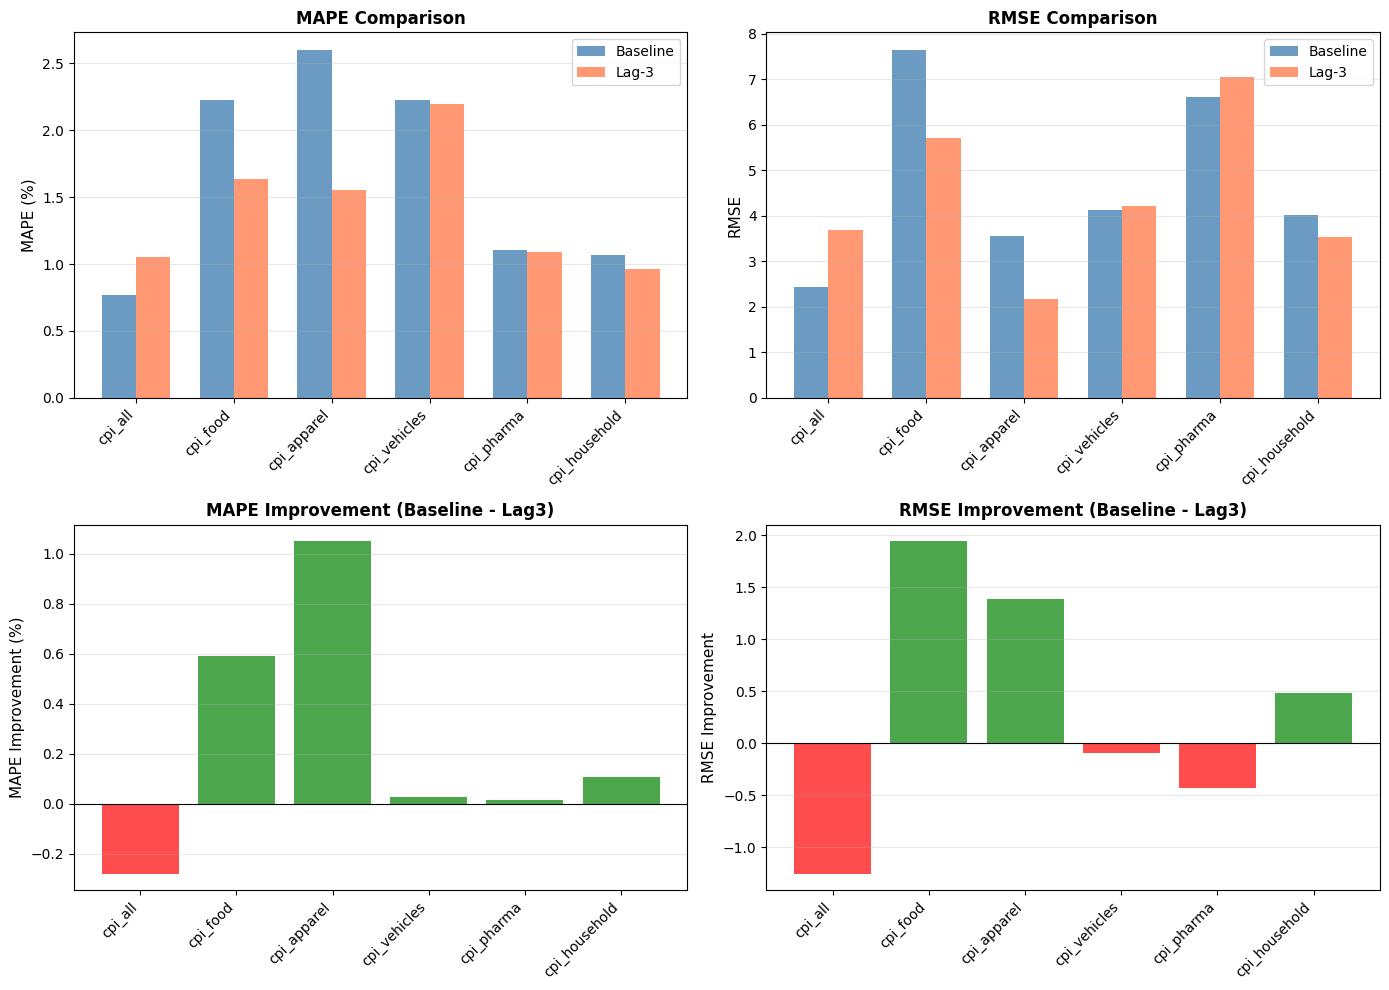

✓ Plot saved to: inflationship_output/sarima_baseline_vs_lag3_comparison.png


In [9]:
if len(results_df) > 0:
    # Filter to well-converged models for cleaner plots
    well_converged = (results_df['baseline_converged'] >= 4) & (results_df['lag3_converged'] >= 4)
    plot_df = results_df[well_converged].copy() if well_converged.sum() > 0 else results_df.copy()
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. MAPE comparison
    ax = axes[0, 0]
    x = np.arange(len(plot_df))
    width = 0.35
    
    ax.bar(x - width/2, plot_df['baseline_mape'], width, label='Baseline', alpha=0.8, color='steelblue')
    ax.bar(x + width/2, plot_df['lag3_mape'], width, label='Lag-3', alpha=0.8, color='coral')
    
    ax.set_ylabel('MAPE (%)', fontsize=11)
    ax.set_title('MAPE Comparison', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df['cpi_series'], rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # 2. RMSE comparison
    ax = axes[0, 1]
    ax.bar(x - width/2, plot_df['baseline_rmse'], width, label='Baseline', alpha=0.8, color='steelblue')
    ax.bar(x + width/2, plot_df['lag3_rmse'], width, label='Lag-3', alpha=0.8, color='coral')
    
    ax.set_ylabel('RMSE', fontsize=11)
    ax.set_title('RMSE Comparison', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df['cpi_series'], rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # 3. MAPE improvement
    ax = axes[1, 0]
    colors = ['green' if val > 0 else 'red' for val in plot_df['mape_improvement']]
    ax.bar(x, plot_df['mape_improvement'], color=colors, alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
    
    ax.set_ylabel('MAPE Improvement (%)', fontsize=11)
    ax.set_title('MAPE Improvement (Baseline - Lag3)', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df['cpi_series'], rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    
    # 4. RMSE improvement
    ax = axes[1, 1]
    colors = ['green' if val > 0 else 'red' for val in plot_df['rmse_improvement']]
    ax.bar(x, plot_df['rmse_improvement'], color=colors, alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
    
    ax.set_ylabel('RMSE Improvement', fontsize=11)
    ax.set_title('RMSE Improvement (Baseline - Lag3)', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df['cpi_series'], rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('inflationship_output/sarima_baseline_vs_lag3_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print('✓ Plot saved to: inflationship_output/sarima_baseline_vs_lag3_comparison.png')
else:
    print('No results to visualize')

## Interpretation Guide

### Understanding the Results

**MAPE (Mean Absolute Percentage Error)**:
- Average % error across all forecasts
- Lower is better
- Example: 2% MAPE means forecasts are off by 2% on average

**RMSE (Root Mean Squared Error)**:
- Measures forecast error in CPI index points
- Lower is better
- Penalizes large errors more than MAPE
- More sensitive to outliers

**Improvement Metrics**:
- **Positive value** = Lag-3 model performed better
- **Negative value** = Baseline model performed better
- Look for consistency: if both MAPE and RMSE improvements are positive, Lag-3 is clearly better

**Convergence**:
- Models should converge in ≥4 out of 5 folds
- Low convergence (0-2 folds) = results unreliable
- Focus analysis on well-converged models only

### Decision Guidelines

1. **If Lag-3 improves MAPE by >0.5%** → Use Lag-3 model
2. **If improvement is -0.5% to +0.5%** → Models are equivalent, use simpler Baseline
3. **If Baseline is >0.5% better** → Stick with Baseline (lag doesn't help)

### Why Lag-3 Might Work

Based on your correlation heatmap, 3-month lags showed:
- Import prices: 0.89 correlation (vs 0.91 current)
- Total empties: 0.75 correlation (vs 0.77 current)

This suggests **delayed transmission** from port activity to CPI:
- Goods arrive at ports → distributed → price changes appear 2-3 months later
- Lag-3 captures this delay directly